# WT vs MUT: Chemical Composition Difference Analysis

This notebook focuses on detecting **chemical composition differences** between
wild-type (WT) and mutant (MUT) butterfly wings using C K-edge spectromicroscopy.

Key design choices that differ from the original `wt_mut_study.ipynb`:

1. **Direct spectral comparison** — no MLP needed; compare absorption & phase
   spectra class-by-class with statistical tests.
2. **Shared normalization** — use a single StandardScaler & phase reference
   so absolute differences are preserved.
3. **δ/β ratio analysis** — directly compute and compare the phase-to-absorption
   ratio (material fingerprint) per semantic class.
4. **Weak-model cross-prediction** — deliberately use a small MLP so that
   subtle chemical differences are amplified.
5. **Peak-level analysis** — compare specific NEXAFS peak positions and heights
   that correspond to known chemical bonds.

In [1]:
import os, random, warnings
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter
from scipy import stats
from skimage.morphology import remove_small_objects, erosion, disk
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

/home/svu/e1547010/myenv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
# ══════════════════════════════════════════════════
# Configuration
# ══════════════════════════════════════════════════

CLASS_NAMES = {
    0: "Lower Lamina",
    1: "Cross Ribs & Ridges",
    2: "Trabeculae",
}

DATASETS = {
    "WT": {
        "path": "./bicyclus_wt_c.h5",
        "roi": (0, 170, 150, 250),
        "test_roi": (0, 170, 250, 350),
        "bg_threshold": 0.85,
        "bg_min_size": 2000,
        "merge": {
            "Trabeculae": [20, 54, 55, 56],
            "Cross Ribs&Ridges": [12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 48, 49, 50, 51, 52, 53, 57, 58],
            "Lower Lamina": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 59],
        },
    },
    "MUT": {
        "path": "./bicyclus_mut_c.h5",
        "roi": (150, 350, 80, 210),
        "test_roi": (150, 350, 211, 350),
        "bg_threshold": 1.60,
        "bg_min_size": 1000,
        "merge": {
            "Trabeculae": [55, 56, 57, 58],
            "Cross Ribs&Ridges": [27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 50, 51, 53, 54, 59],
            "Lower Lamina": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 43, 44, 45, 46, 47, 48, 49, 52],
        },
    },
}

COMMON_CFG = {
    "chosen_energy": 290.0,
    "preedge_cutoff": 285.0,
    "energy_grid": np.arange(280.0, 310.0, 1.0),
    "cluster_k": 60,
    "cluster_neighbors": 30,
    "cluster_min_dist": 0.10,
    "cluster_area_weight": 0.50,
}

EGRID = COMMON_CFG["energy_grid"]
print(f"Energy grid: {EGRID[0]:.0f} – {EGRID[-1]:.0f} eV, {len(EGRID)} points")

Energy grid: 280 – 309 eV, 30 points


In [3]:
# ══════════════════════════════════════════════════
# Helper functions (same as wt_mut_study.ipynb)
# ══════════════════════════════════════════════════

def circular_mean(theta, axis=0):
    return np.angle(np.mean(np.exp(1j * theta), axis=axis))


def interp_cube_linear(cube, energy_src, energy_dst):
    e_in, h, w = cube.shape
    flat = cube.reshape(e_in, -1)
    fn = interp1d(energy_src, flat, axis=0, kind="linear",
                  bounds_error=False, fill_value="extrapolate")
    return fn(energy_dst).astype(np.float32).reshape(len(energy_dst), h, w)


def interp_phase_cube(phase_cube, energy_src, energy_dst):
    sin_i = interp_cube_linear(np.sin(phase_cube), energy_src, energy_dst)
    cos_i = interp_cube_linear(np.cos(phase_cube), energy_src, energy_dst)
    return np.angle(cos_i + 1j * sin_i)


def load_and_preprocess(name, cfg, common_cfg):
    path = cfg["path"]
    assert os.path.exists(path), f"Missing: {path}"
    with h5py.File(path, "r") as f:
        amplitude_im = np.asarray(f["amplitude"], dtype=np.float32)
        phase_im     = np.asarray(f["phase"],     dtype=np.float32)
        energy       = np.asarray(f["energy_ev"], dtype=np.float32)

    eidx = int(np.argmin(np.abs(energy - common_cfg["chosen_energy"])))
    img = amplitude_im[eidx]

    bg_mask = img >= cfg["bg_threshold"]
    bg_mask = remove_small_objects(bg_mask, min_size=cfg["bg_min_size"])
    bg_mask = erosion(bg_mask, disk(1))

    bg_mean = amplitude_im[:, bg_mask].mean(axis=1)
    bg_phase = phase_im[:, bg_mask]
    phase_bg_mean = np.angle(np.mean(np.exp(1j * bg_phase), axis=1))

    eps = 1e-1
    bg_r = bg_mean.reshape(-1, 1, 1)
    absorption = -2.0 * np.log((np.abs(amplitude_im) + eps) / (np.abs(bg_r) + eps))
    phase_corrected = np.angle(np.exp(1j * (phase_im - phase_bg_mean[:, None, None])))

    absorption_masked = absorption.copy()
    absorption_masked[:, bg_mask] = np.nan
    phase_masked = phase_corrected.copy()
    phase_masked[:, bg_mask] = np.nan

    # preedge removal
    data_cube = absorption_masked.copy()
    mask_pre = energy < common_cfg["preedge_cutoff"]
    e_pre = energy[mask_pre]; e0 = float(e_pre.min()); d_e = e_pre - e0
    pre_flat = data_cube[mask_pre].reshape(len(e_pre), -1)
    valid_cols = np.all(np.isfinite(pre_flat), axis=0) & np.all(pre_flat > 0, axis=0)
    A_fit = np.full(pre_flat.shape[1], np.nan, np.float32)
    B_fit = np.full(pre_flat.shape[1], np.nan, np.float32)
    if np.any(valid_cols):
        y = np.log(np.maximum(pre_flat[:, valid_cols], 1e-8))
        x = d_e[:, None]
        xm, ym = x.mean(0), y.mean(0)
        slope = ((x - xm) * (y - ym)).sum(0) / np.maximum(((x - xm)**2).sum(0), 1e-8)
        A_fit[valid_cols] = np.exp(ym - slope * xm).astype(np.float32)
        B_fit[valid_cols] = (-slope).astype(np.float32)
    h, w = bg_mask.shape
    A_fit = A_fit.reshape(h, w); B_fit = B_fit.reshape(h, w)
    d_e_full = (energy - e0)[:, None, None]
    baseline = A_fit[None] * np.exp(-B_fit[None] * d_e_full)
    preedge_removed = np.maximum(data_cube - baseline, 0.0)
    preedge_removed[:, bg_mask] = np.nan

    x1, x2, y1, y2 = cfg["roi"]
    foreground_mask = ~bg_mask
    test_roi = cfg.get("test_roi")
    if test_roi is not None:
        tx1, tx2, ty1, ty2 = test_roi
        test_mask = np.zeros_like(foreground_mask)
        test_mask[ty1:ty2, tx1:tx2] = True
        test_mask = test_mask & foreground_mask
    else:
        test_mask = foreground_mask.copy()
        test_mask[y1:y2, x1:x2] = False

    abs_interp   = interp_cube_linear(absorption_masked, energy, EGRID)
    phase_interp = interp_phase_cube(phase_masked, energy, EGRID)

    return {
        "name": name, "energy": energy,
        "amplitude_im": amplitude_im, "phase_im": phase_im,
        "bg_mask": bg_mask, "foreground_mask": foreground_mask,
        "roi": (x1, x2, y1, y2), "test_mask": test_mask,
        "absorption_masked": absorption_masked,
        "phase_masked": phase_masked,
        "preedge_removed": preedge_removed,
        "avg_absorbance": np.nanmean(absorption_masked, axis=0),
        "abs_interp": abs_interp,
        "phase_interp": phase_interp,
    }


def cluster_full_wing(data, cfg, common_cfg):
    cube = data["preedge_removed"]
    e_len, h, w = cube.shape
    x = cube.transpose(1, 2, 0).reshape(-1, e_len)
    valid = (~data["bg_mask"].reshape(-1)) & (~np.isnan(x).any(axis=1))
    xv = x[valid]
    area = xv.sum(axis=1, keepdims=True)
    xfeat = np.hstack([xv, common_cfg["cluster_area_weight"] * area])
    scaler = StandardScaler()
    xv_s = scaler.fit_transform(xfeat)
    reducer = umap.UMAP(n_components=2, n_neighbors=common_cfg["cluster_neighbors"],
                        min_dist=common_cfg["cluster_min_dist"],
                        metric="euclidean", random_state=SEED)
    emb = reducer.fit_transform(xv_s)
    kmeans = KMeans(n_clusters=common_cfg["cluster_k"], random_state=SEED, n_init="auto")
    labels_v = kmeans.fit_predict(emb)
    centers = kmeans.cluster_centers_
    start = np.argmin(centers[:, 0])
    unused = set(range(common_cfg["cluster_k"])); unused.remove(start)
    order = [start]
    while unused:
        rest = np.array(list(unused))
        nxt = rest[np.argmin(np.linalg.norm(centers[rest] - centers[order[-1]], axis=1))]
        order.append(nxt); unused.remove(nxt)
    old_to_new = np.empty(common_cfg["cluster_k"], dtype=int)
    for new_id, old_id in enumerate(order):
        old_to_new[old_id] = new_id
    labels_v = old_to_new[labels_v]
    labels_flat = np.full(h * w, -1, dtype=np.int32)
    labels_flat[valid] = labels_v
    labels_full = labels_flat.reshape(h, w)
    sem = np.full_like(labels_full, -1, dtype=np.int32)
    sem[np.isin(labels_full, cfg["merge"]["Lower Lamina"])] = 0
    sem[np.isin(labels_full, cfg["merge"]["Cross Ribs&Ridges"])] = 1
    sem[np.isin(labels_full, cfg["merge"]["Trabeculae"])] = 2
    data["semantic_full"] = sem
    data["cluster_labels_full"] = labels_full
    return data


print("Helpers loaded.")

Helpers loaded.


In [4]:
# ══════════════════════════════════════════════════
# Load & cluster
# ══════════════════════════════════════════════════
datasets = {}
for name, cfg in DATASETS.items():
    print(f"Loading {name} ...")
    data = load_and_preprocess(name, cfg, COMMON_CFG)
    print(f"Clustering {name} ...")
    data = cluster_full_wing(data, cfg, COMMON_CFG)
    datasets[name] = data

for name, data in datasets.items():
    fg = data["foreground_mask"].sum()
    tm = data["test_mask"].sum()
    print(f"{name}: foreground={fg}, test_pixels={tm}")

Loading WT ...
Clustering WT ...
Loading MUT ...
Clustering MUT ...
WT: foreground=83637, test_pixels=17000
MUT: foreground=115317, test_pixels=27800


---
## 1. Direct Spectral Comparison (Absorption)

Compare the **mean absorption spectra** of WT vs MUT for each semantic class.
If there are chemical differences, the NEXAFS fine-structure peaks should differ.

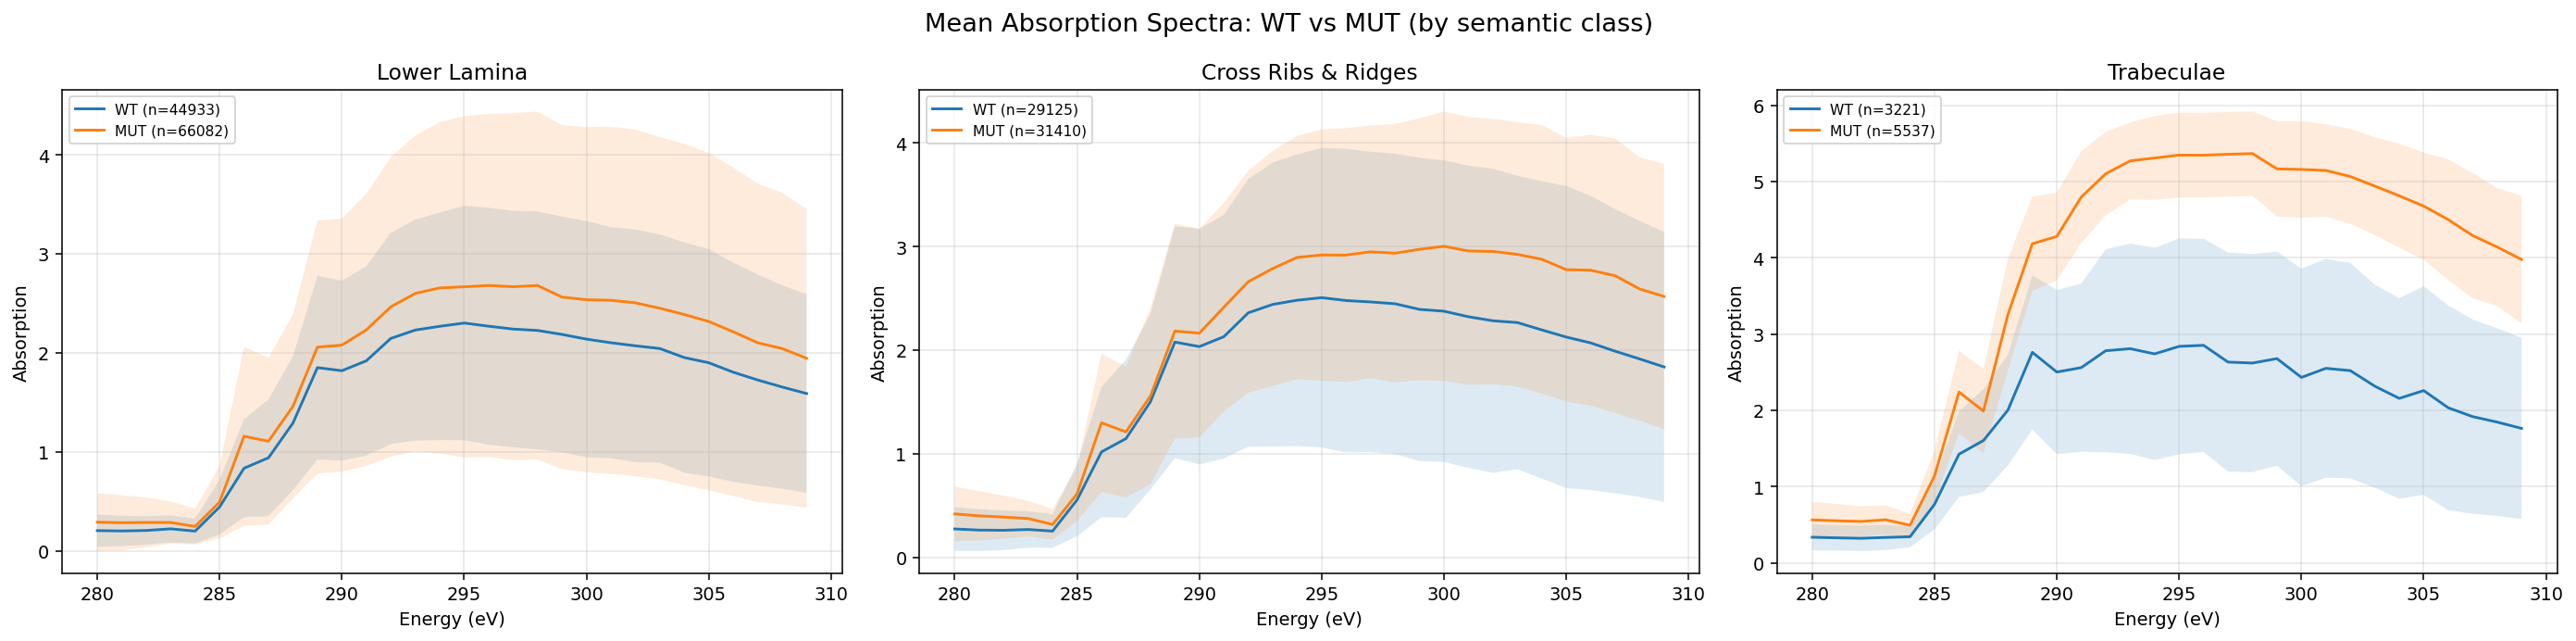

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=140)

for class_id, class_name in CLASS_NAMES.items():
    ax = axes[class_id]
    for dname in ["WT", "MUT"]:
        d = datasets[dname]
        mask = (d["semantic_full"] == class_id) & d["foreground_mask"]
        if mask.sum() == 0:
            continue
        spec = d["abs_interp"][:, mask]
        mean_s = np.nanmean(spec, axis=1)
        std_s  = np.nanstd(spec, axis=1)
        sem_s  = std_s / np.sqrt(mask.sum())
        ax.plot(EGRID, mean_s, label=f"{dname} (n={mask.sum()})")
        ax.fill_between(EGRID, mean_s - std_s, mean_s + std_s, alpha=0.15)
    ax.set_title(class_name)
    ax.set_xlabel("Energy (eV)")
    ax.set_ylabel("Absorption")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Mean Absorption Spectra: WT vs MUT (by semantic class)", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Absorption Difference Spectra

Plot **(MUT − WT)** difference for each class. Non-zero differences indicate
chemical composition or thickness/density variations.

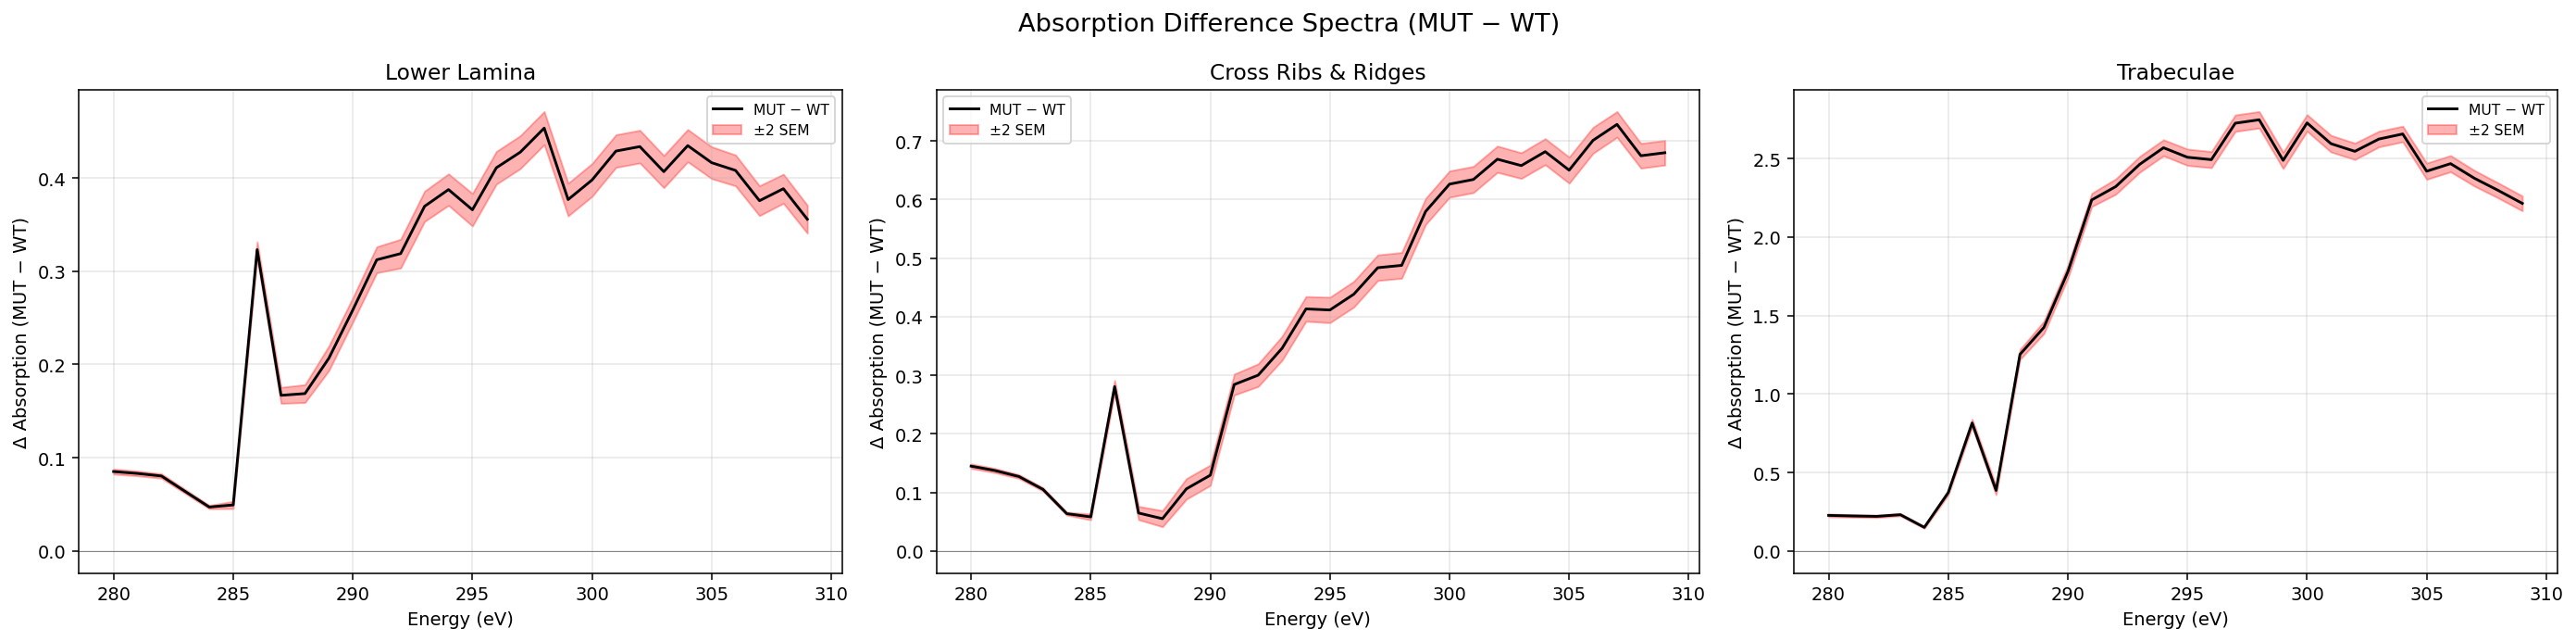

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=140)

for class_id, class_name in CLASS_NAMES.items():
    ax = axes[class_id]
    means = {}
    stds  = {}
    ns    = {}
    for dname in ["WT", "MUT"]:
        d = datasets[dname]
        mask = (d["semantic_full"] == class_id) & d["foreground_mask"]
        spec = d["abs_interp"][:, mask]
        means[dname] = np.nanmean(spec, axis=1)
        stds[dname]  = np.nanstd(spec, axis=1)
        ns[dname]    = mask.sum()

    diff = means["MUT"] - means["WT"]
    # propagated SEM
    sem_diff = np.sqrt((stds["WT"]**2 / ns["WT"]) + (stds["MUT"]**2 / ns["MUT"]))

    ax.axhline(0, color="gray", lw=0.5)
    ax.plot(EGRID, diff, "k-", lw=1.5, label="MUT − WT")
    ax.fill_between(EGRID, diff - 2*sem_diff, diff + 2*sem_diff,
                    alpha=0.3, color="red", label="±2 SEM")
    ax.set_title(f"{class_name}")
    ax.set_xlabel("Energy (eV)")
    ax.set_ylabel("Δ Absorption (MUT − WT)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Absorption Difference Spectra (MUT − WT)", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Phase Spectra Comparison

Same comparison but for phase, which is sensitive to electron density × thickness.

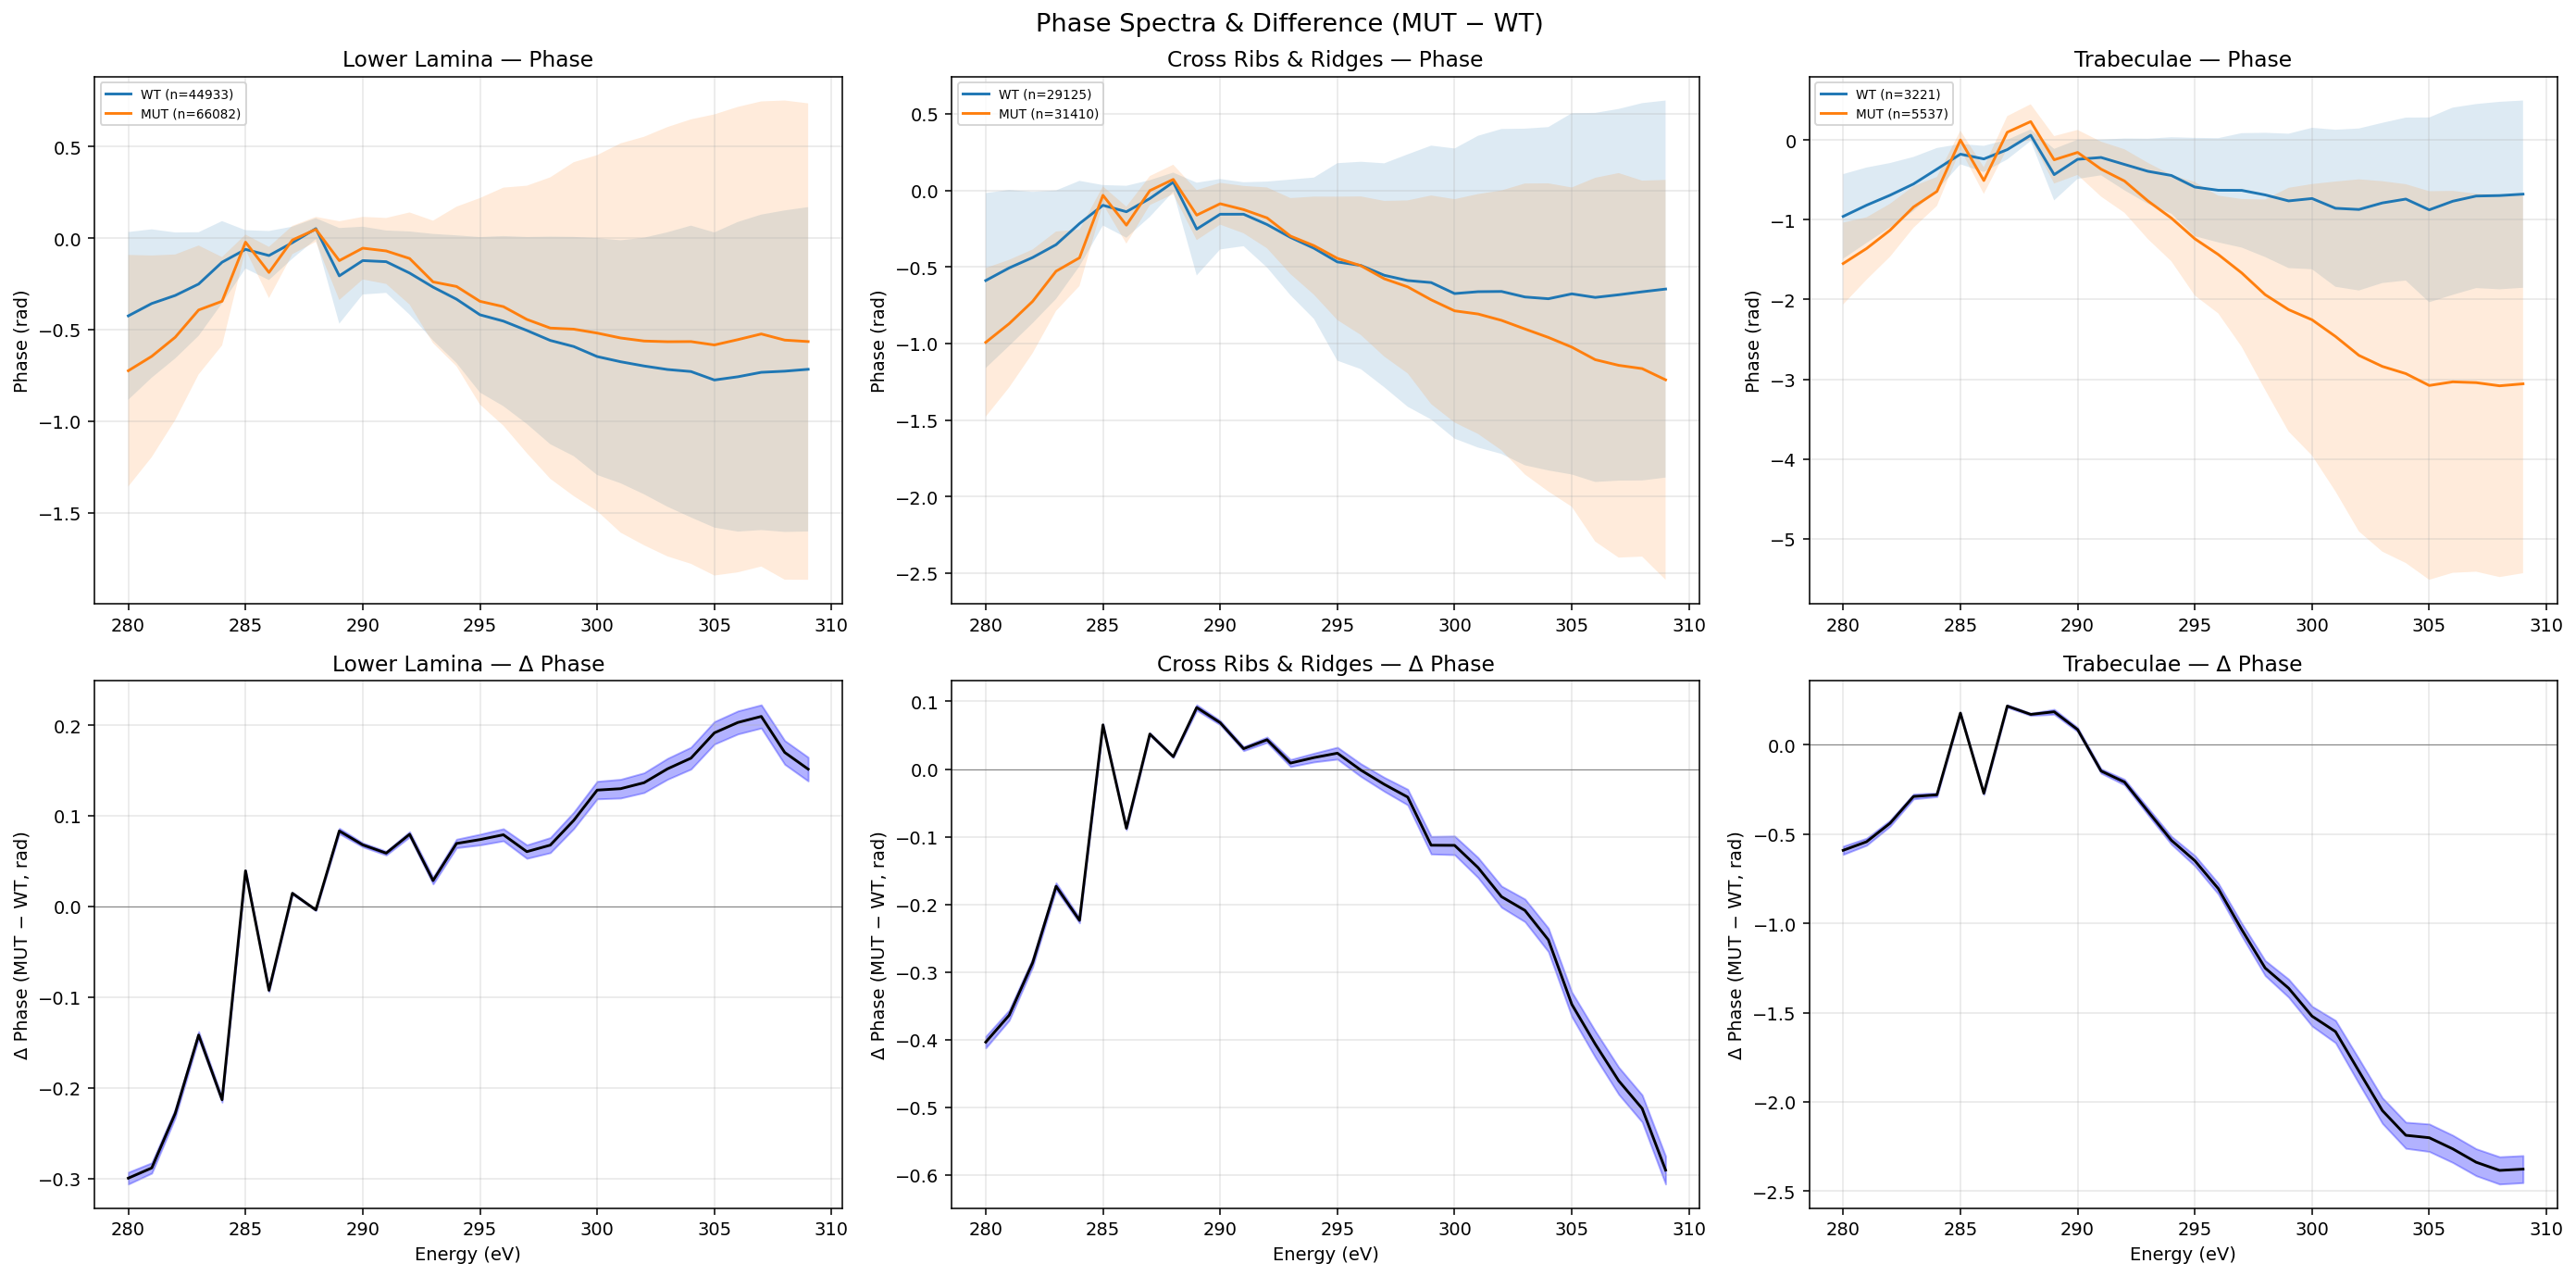

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10), dpi=140)

for class_id, class_name in CLASS_NAMES.items():
    ax_abs  = axes[0, class_id]
    ax_diff = axes[1, class_id]
    means_ph = {}
    stds_ph  = {}
    ns_ph    = {}

    for dname in ["WT", "MUT"]:
        d = datasets[dname]
        mask = (d["semantic_full"] == class_id) & d["foreground_mask"]
        ph = d["phase_interp"][:, mask]
        means_ph[dname] = circular_mean(ph, axis=1)
        stds_ph[dname]  = np.std(ph, axis=1)
        ns_ph[dname]    = mask.sum()
        ax_abs.plot(EGRID, means_ph[dname], label=f"{dname} (n={mask.sum()})")
        ax_abs.fill_between(EGRID,
                            means_ph[dname] - stds_ph[dname],
                            means_ph[dname] + stds_ph[dname], alpha=0.15)

    diff_ph = means_ph["MUT"] - means_ph["WT"]
    sem_ph  = np.sqrt((stds_ph["WT"]**2 / ns_ph["WT"]) +
                      (stds_ph["MUT"]**2 / ns_ph["MUT"]))
    ax_diff.axhline(0, color="gray", lw=0.5)
    ax_diff.plot(EGRID, diff_ph, "k-", lw=1.5)
    ax_diff.fill_between(EGRID, diff_ph - 2*sem_ph, diff_ph + 2*sem_ph,
                         alpha=0.3, color="blue")

    ax_abs.set_title(f"{class_name} — Phase")
    ax_abs.set_ylabel("Phase (rad)"); ax_abs.legend(fontsize=7); ax_abs.grid(alpha=0.3)
    ax_diff.set_title(f"{class_name} — Δ Phase")
    ax_diff.set_xlabel("Energy (eV)")
    ax_diff.set_ylabel("Δ Phase (MUT − WT, rad)")
    ax_diff.grid(alpha=0.3)

plt.suptitle("Phase Spectra & Difference (MUT − WT)", fontsize=14)
plt.tight_layout()
plt.show()

## 4. δ/β Ratio — Material Fingerprint

The ratio `phase / absorption ∝ δ(E) / β(E)` is a **pure material property**
independent of sample thickness. If this ratio differs between WT and MUT,
their chemical composition must be different.

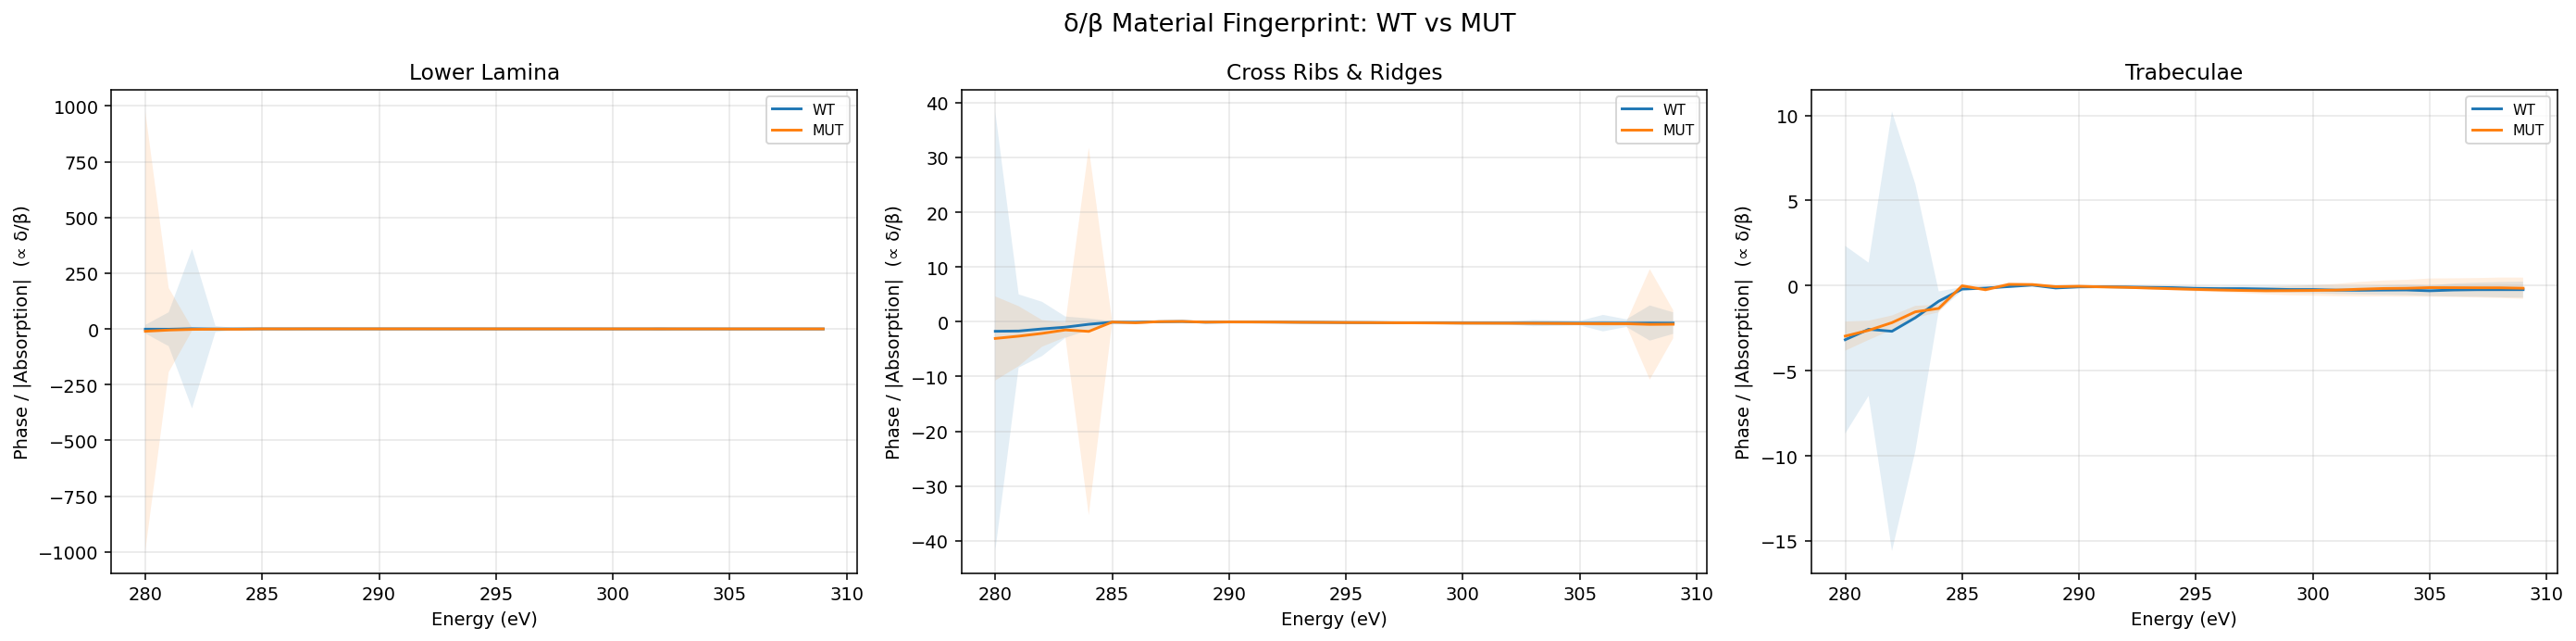

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=140)

for class_id, class_name in CLASS_NAMES.items():
    ax = axes[class_id]
    for dname in ["WT", "MUT"]:
        d = datasets[dname]
        mask = (d["semantic_full"] == class_id) & d["foreground_mask"]
        if mask.sum() < 10:
            continue
        abs_spec = d["abs_interp"][:, mask]   # (E, N)
        ph_spec  = d["phase_interp"][:, mask]

        # per-pixel ratio, then average across pixels
        eps = 1e-6
        ratio = ph_spec / np.clip(np.abs(abs_spec), eps, None)
        ratio_mean = np.nanmean(ratio, axis=1)
        ratio_std  = np.nanstd(ratio, axis=1)

        ax.plot(EGRID, ratio_mean, label=f"{dname}")
        ax.fill_between(EGRID, ratio_mean - ratio_std, ratio_mean + ratio_std, alpha=0.12)

    ax.set_title(class_name)
    ax.set_xlabel("Energy (eV)")
    ax.set_ylabel("Phase / |Absorption|  (∝ δ/β)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("δ/β Material Fingerprint: WT vs MUT", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Energy-by-Energy Statistical Test

At each energy point, perform a Welch t-test on the absorption values
between WT and MUT pixels of the same semantic class.

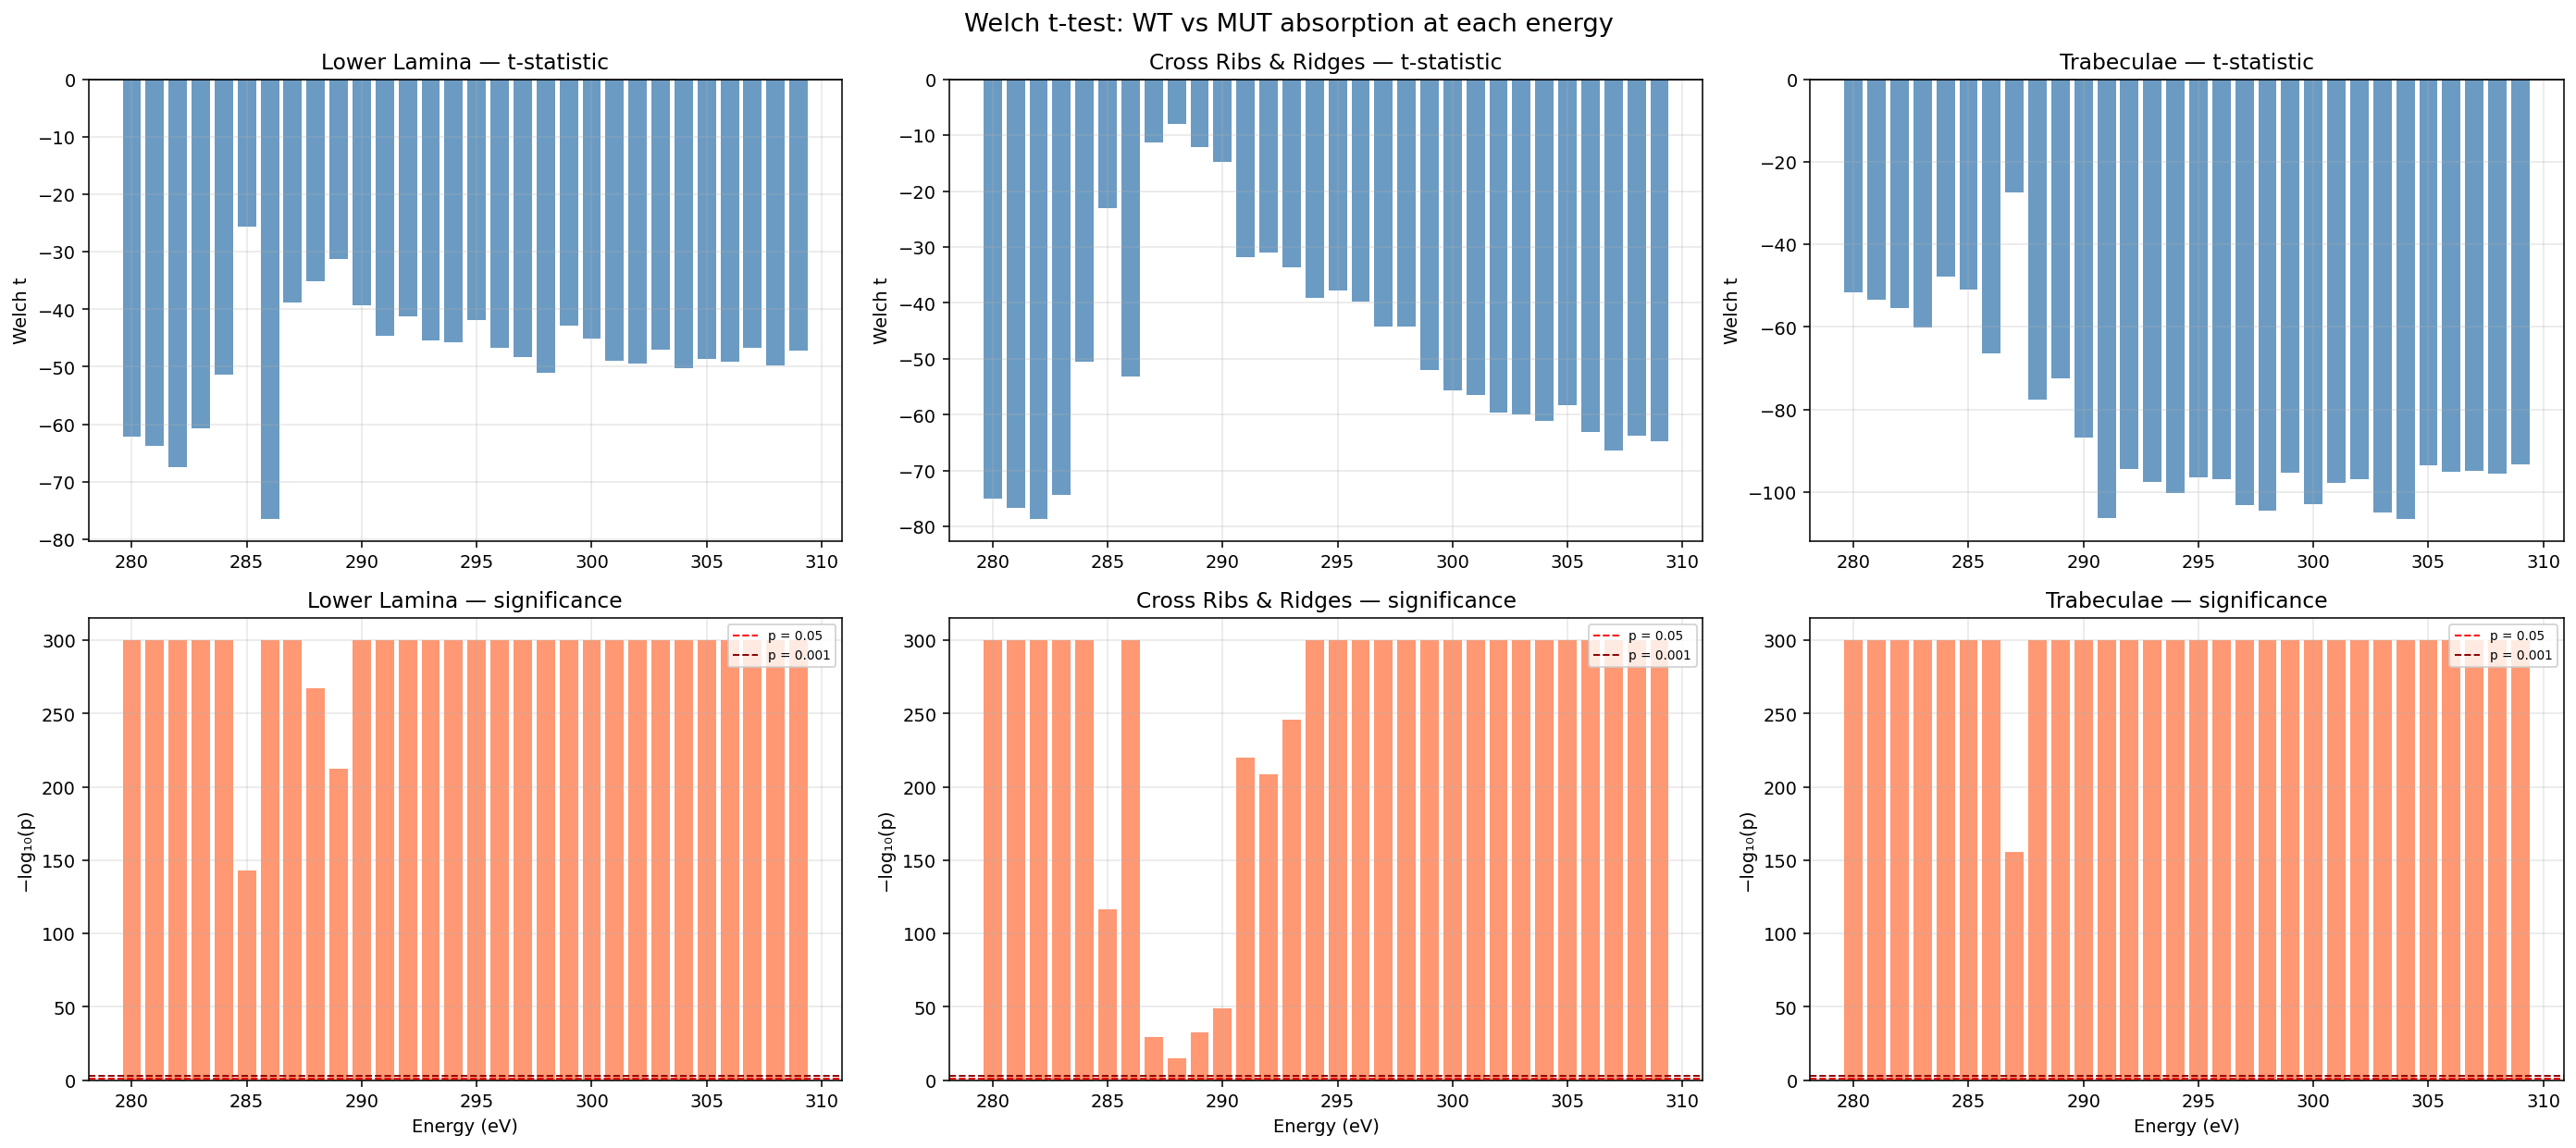

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(20, 9), dpi=140)

for class_id, class_name in CLASS_NAMES.items():
    ax_t = axes[0, class_id]
    ax_p = axes[1, class_id]

    t_vals = []
    p_vals = []

    wt_d  = datasets["WT"]
    mut_d = datasets["MUT"]
    wt_mask  = (wt_d["semantic_full"]  == class_id) & wt_d["foreground_mask"]
    mut_mask = (mut_d["semantic_full"] == class_id) & mut_d["foreground_mask"]

    for ei in range(len(EGRID)):
        a_wt  = wt_d["abs_interp"][ei][wt_mask]
        a_mut = mut_d["abs_interp"][ei][mut_mask]
        a_wt  = a_wt[np.isfinite(a_wt)]
        a_mut = a_mut[np.isfinite(a_mut)]
        if len(a_wt) > 2 and len(a_mut) > 2:
            t, p = stats.ttest_ind(a_wt, a_mut, equal_var=False)
        else:
            t, p = 0.0, 1.0
        t_vals.append(t)
        p_vals.append(p)

    t_vals = np.array(t_vals)
    p_vals = np.array(p_vals)

    ax_t.bar(EGRID, t_vals, width=0.8, color="steelblue", alpha=0.8)
    ax_t.axhline(0, color="k", lw=0.5)
    ax_t.set_title(f"{class_name} — t-statistic")
    ax_t.set_ylabel("Welch t")
    ax_t.grid(alpha=0.3)

    ax_p.bar(EGRID, -np.log10(np.clip(p_vals, 1e-300, 1.0)), width=0.8,
             color="coral", alpha=0.8)
    ax_p.axhline(-np.log10(0.05), color="red", ls="--", lw=1, label="p = 0.05")
    ax_p.axhline(-np.log10(0.001), color="darkred", ls="--", lw=1, label="p = 0.001")
    ax_p.set_title(f"{class_name} — significance")
    ax_p.set_xlabel("Energy (eV)")
    ax_p.set_ylabel("−log₁₀(p)")
    ax_p.legend(fontsize=7)
    ax_p.grid(alpha=0.3)

plt.suptitle("Welch t-test: WT vs MUT absorption at each energy", fontsize=14)
plt.tight_layout()
plt.show()

## 6. NEXAFS Peak Analysis

Extract the position and height of the strongest absorption peak for each pixel,
then compare the distributions between WT and MUT.

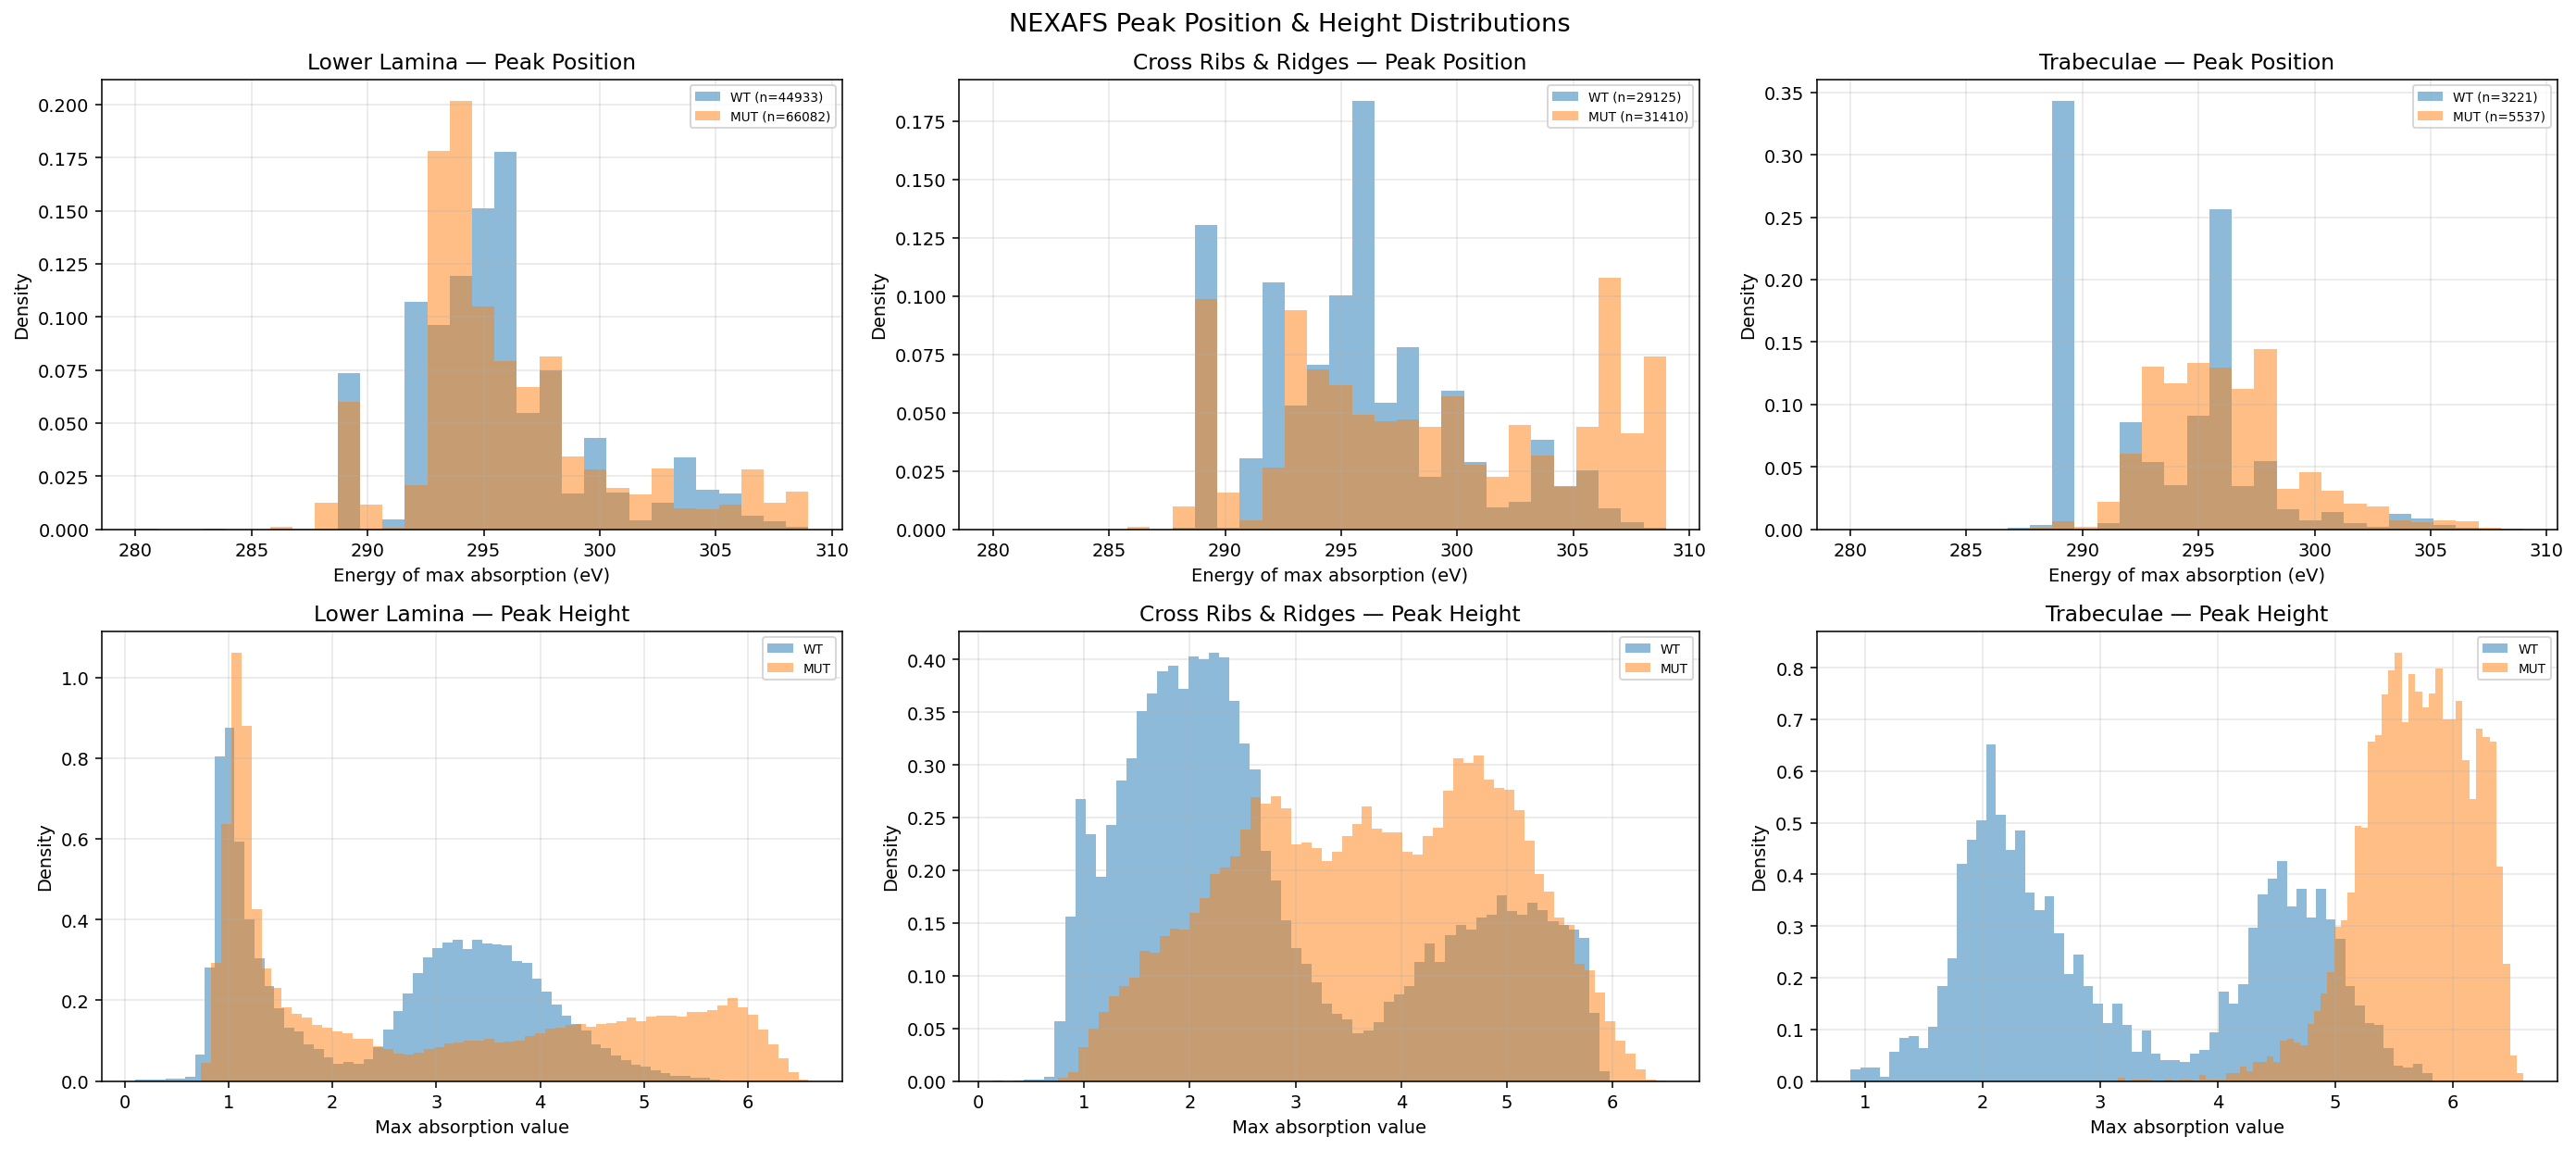

In [10]:
def pixel_peak_energy(abs_interp, mask, egrid):
    """For each pixel in mask, find the energy of the maximum absorption."""
    spec = abs_interp[:, mask]  # (E, N)
    peak_idx = np.nanargmax(spec, axis=0)
    peak_e = egrid[peak_idx]
    peak_h = spec[peak_idx, np.arange(spec.shape[1])]
    valid = np.isfinite(peak_h)
    return peak_e[valid], peak_h[valid]


fig, axes = plt.subplots(2, 3, figsize=(20, 9), dpi=140)

for class_id, class_name in CLASS_NAMES.items():
    ax_pos = axes[0, class_id]
    ax_ht  = axes[1, class_id]

    for dname, color in [("WT", "C0"), ("MUT", "C1")]:
        d = datasets[dname]
        mask = (d["semantic_full"] == class_id) & d["foreground_mask"]
        if mask.sum() < 10:
            continue
        pe, ph = pixel_peak_energy(d["abs_interp"], mask, EGRID)

        ax_pos.hist(pe, bins=len(EGRID), range=(EGRID[0], EGRID[-1]),
                    alpha=0.5, color=color, label=f"{dname} (n={len(pe)})",
                    density=True)
        ax_ht.hist(ph, bins=60, alpha=0.5, color=color,
                   label=f"{dname}", density=True)

    ax_pos.set_title(f"{class_name} — Peak Position")
    ax_pos.set_xlabel("Energy of max absorption (eV)")
    ax_pos.set_ylabel("Density")
    ax_pos.legend(fontsize=7)
    ax_pos.grid(alpha=0.3)

    ax_ht.set_title(f"{class_name} — Peak Height")
    ax_ht.set_xlabel("Max absorption value")
    ax_ht.set_ylabel("Density")
    ax_ht.legend(fontsize=7)
    ax_ht.grid(alpha=0.3)

plt.suptitle("NEXAFS Peak Position & Height Distributions", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Semantic Class Proportions

Even if the spectral shapes are identical, the *proportions* of
structural elements may differ between WT and MUT.

,Dataset,Class,Pixels,Fraction
0,WT,Lower Lamina,44933,0.537238
1,WT,Cross Ribs & Ridges,29125,0.348231
2,WT,Trabeculae,3221,0.038512
3,MUT,Lower Lamina,66082,0.573046
4,MUT,Cross Ribs & Ridges,31410,0.272380
5,MUT,Trabeculae,5537,0.048015


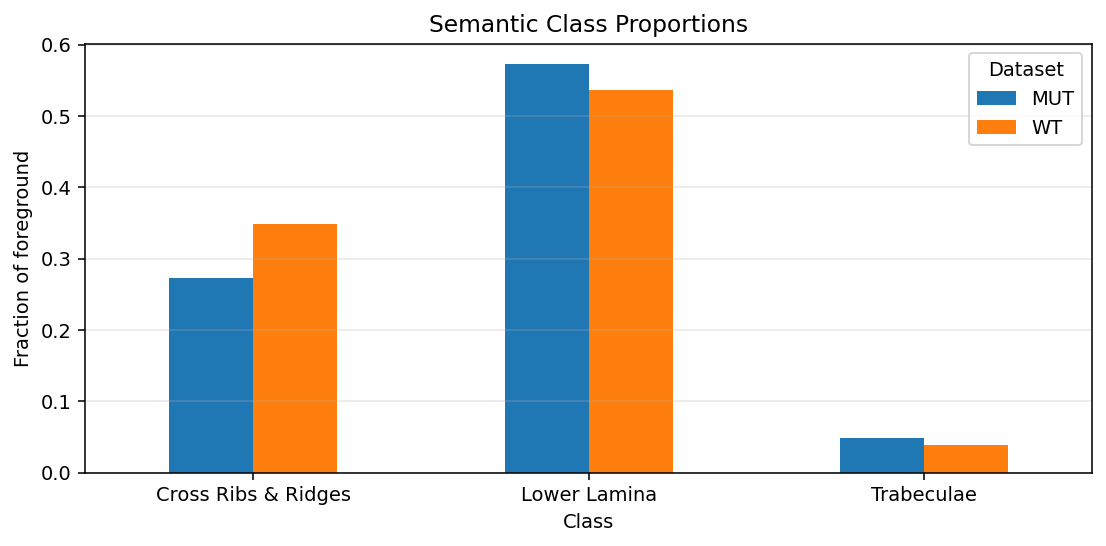

In [11]:
rows = []
for dname, d in datasets.items():
    fg_count = max(int(d["foreground_mask"].sum()), 1)
    for cid, cname in CLASS_NAMES.items():
        n = int((d["semantic_full"] == cid).sum())
        rows.append({"Dataset": dname, "Class": cname,
                     "Pixels": n, "Fraction": n / fg_count})

frac_df = pd.DataFrame(rows)
display(frac_df)

fig, ax = plt.subplots(figsize=(8, 4), dpi=140)
pivot = frac_df.pivot(index="Class", columns="Dataset", values="Fraction")
pivot.plot.bar(ax=ax, rot=0)
ax.set_ylabel("Fraction of foreground")
ax.set_title("Semantic Class Proportions")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 8. Joint UMAP of Pixel Spectra (WT + MUT)

Pool all foreground pixel spectra from both wings into one UMAP embedding.
If chemical composition differs, WT and MUT pixels should form separate clusters.

In [12]:
specs  = []
labels = []
domains = []
MAX_PER_DATASET = 15000

for dname, d in datasets.items():
    mask = d["foreground_mask"] & (d["semantic_full"] >= 0)
    s = d["abs_interp"][:, mask].T  # (N, E)
    c = d["semantic_full"][mask]
    valid = np.all(np.isfinite(s), axis=1)
    s, c = s[valid], c[valid]
    if len(s) > MAX_PER_DATASET:
        idx = np.random.choice(len(s), MAX_PER_DATASET, replace=False)
        s, c = s[idx], c[idx]
    specs.append(s)
    labels.append(c)
    domains.append(np.full(len(s), dname, dtype=object))

X_all = np.vstack(specs).astype(np.float32)
L_all = np.concatenate(labels)
D_all = np.concatenate(domains)

# shared scaler
scaler_joint = StandardScaler()
X_s = scaler_joint.fit_transform(X_all)

print(f"Joint UMAP on {len(X_s)} pixels ...")
emb2d = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                   metric="euclidean", random_state=SEED).fit_transform(X_s)
print("Done.")

Joint UMAP on 30000 pixels ...
Done.


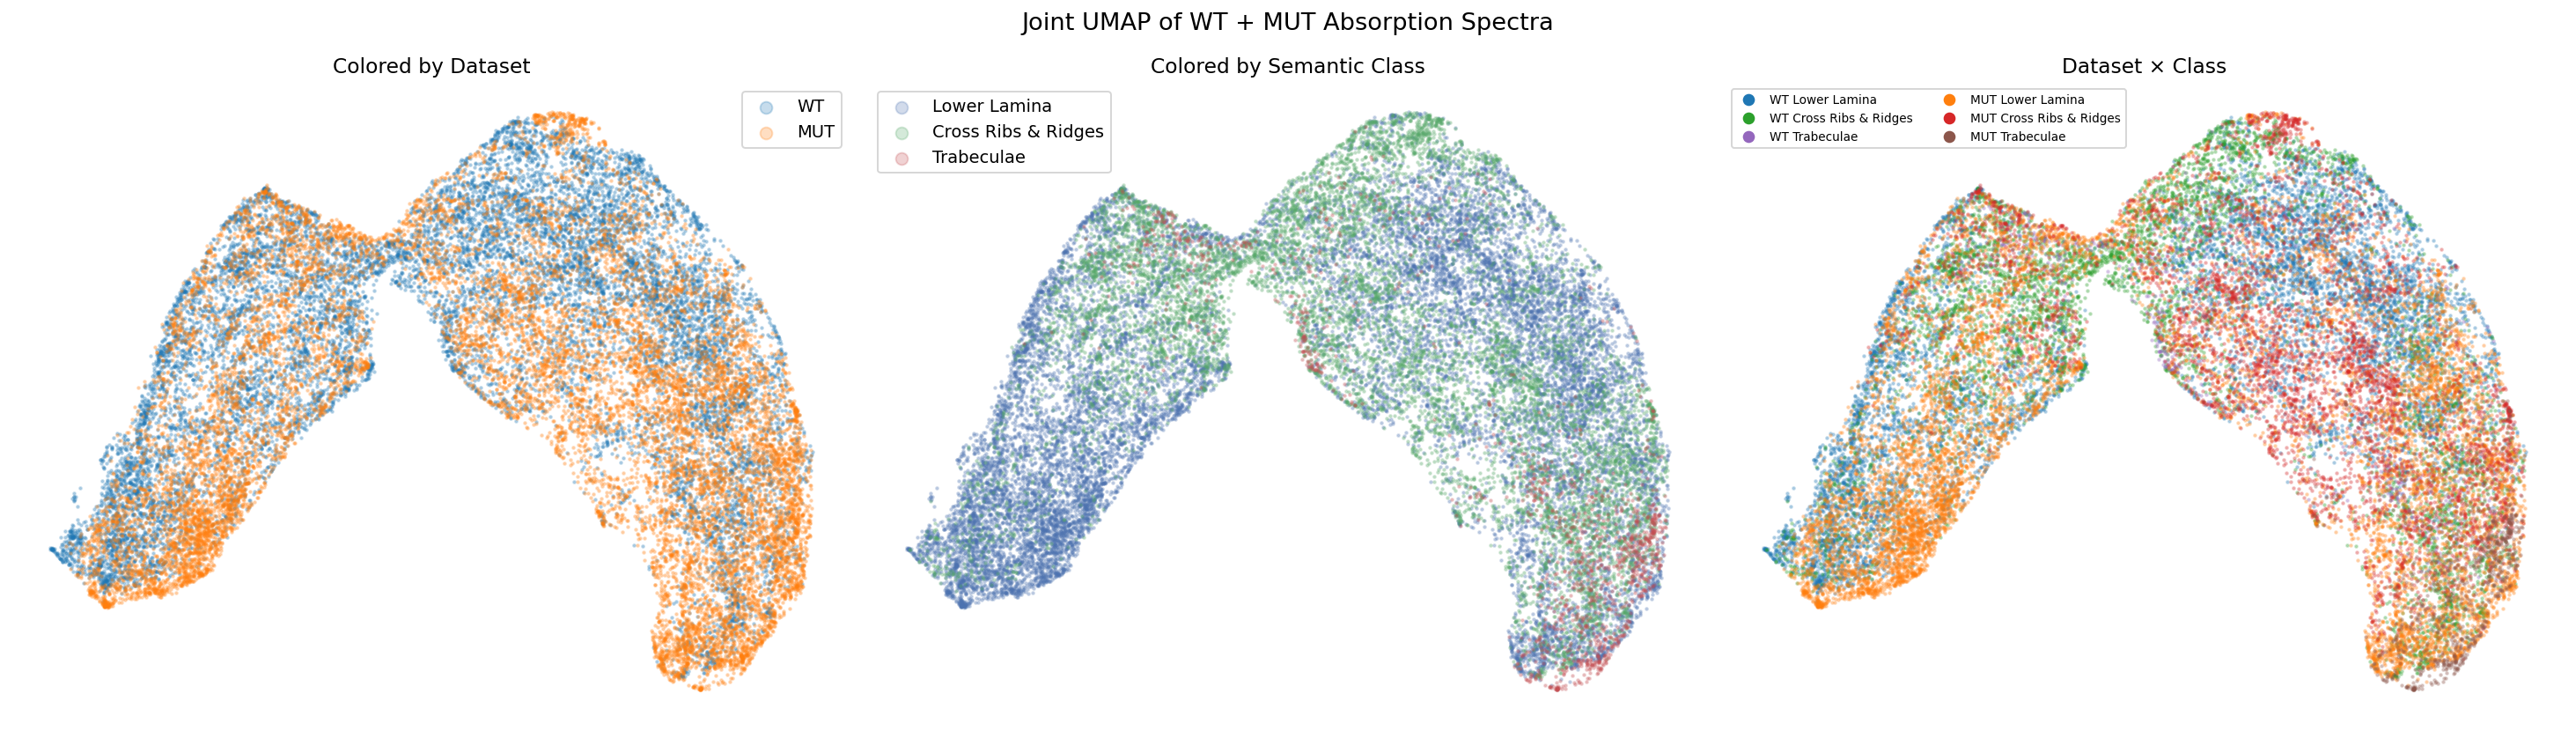

In [13]:
colors = {
    ("WT", 0): "#1f77b4", ("WT", 1): "#2ca02c", ("WT", 2): "#9467bd",
    ("MUT", 0): "#ff7f0e", ("MUT", 1): "#d62728", ("MUT", 2): "#8c564b",
}

fig, axes = plt.subplots(1, 3, figsize=(21, 6), dpi=140)

# left: colored by dataset
ax = axes[0]
for dn, col in [("WT", "#1f77b4"), ("MUT", "#ff7f0e")]:
    m = D_all == dn
    ax.scatter(emb2d[m, 0], emb2d[m, 1], s=2, alpha=0.25, c=col, label=dn)
ax.set_title("Colored by Dataset"); ax.legend(markerscale=5); ax.axis("off")

# middle: colored by class
ax = axes[1]
class_colors = {0: "#4c72b0", 1: "#55a868", 2: "#c44e52"}
for cid, cname in CLASS_NAMES.items():
    m = L_all == cid
    ax.scatter(emb2d[m, 0], emb2d[m, 1], s=2, alpha=0.25,
              c=class_colors[cid], label=cname)
ax.set_title("Colored by Semantic Class"); ax.legend(markerscale=5); ax.axis("off")

# right: colored by dataset × class
ax = axes[2]
from matplotlib.lines import Line2D
for dn in ["WT", "MUT"]:
    for cid in CLASS_NAMES:
        m = (D_all == dn) & (L_all == cid)
        ax.scatter(emb2d[m, 0], emb2d[m, 1], s=2, alpha=0.25, c=colors[(dn, cid)])
legend_els = [Line2D([0],[0], marker="o", ls="", color=colors[(dn,cid)],
              label=f"{dn} {CLASS_NAMES[cid]}", markersize=6)
              for dn in ["WT","MUT"] for cid in CLASS_NAMES]
ax.legend(handles=legend_els, fontsize=7, ncol=2)
ax.set_title("Dataset × Class"); ax.axis("off")

plt.suptitle("Joint UMAP of WT + MUT Absorption Spectra", fontsize=14)
plt.tight_layout()
plt.show()

## 9. Weak-Model Cross-Prediction

Use a **deliberately small MLP** (1 hidden layer, 32 units) with **shared
normalization** so that even subtle chemical differences cause cross-domain
prediction to degrade.

In [14]:
class TinyMLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, x):
        return self.net(x)


def angular_error(pred, true):
    return np.angle(np.exp(1j * (pred - true)))


def build_shared_data():
    """Build train/val sets using SHARED scaler & phase_ref across both datasets."""
    all_abs, all_phase, all_cls, all_domain = [], [], [], []
    for dname, d in datasets.items():
        x1, x2, y1, y2 = d["roi"]
        abs_roi   = d["abs_interp"][:, y1:y2, x1:x2]
        phase_roi = d["phase_interp"][:, y1:y2, x1:x2]
        sem_full  = d["semantic_full"]
        cls_roi   = sem_full[y1:y2, x1:x2]

        dd, hh, ww = abs_roi.shape
        a = abs_roi.transpose(1, 2, 0).reshape(-1, dd)
        p = phase_roi.transpose(1, 2, 0).reshape(-1, dd)
        c = cls_roi.reshape(-1)
        v = np.all(np.isfinite(a), 1) & np.all(np.isfinite(p), 1) & (c >= 0)
        all_abs.append(a[v]); all_phase.append(p[v])
        all_cls.append(c[v])
        all_domain.append(np.full(v.sum(), dname, dtype=object))

    X = np.vstack(all_abs).astype(np.float32)
    P = np.vstack(all_phase).astype(np.float32)
    C = np.concatenate(all_cls)
    D = np.concatenate(all_domain)
    d_dim = X.shape[1]

    # shared phase reference (Lower Lamina from BOTH datasets)
    ref_mask = C == 0
    phase_ref = circular_mean(P[ref_mask], axis=0).astype(np.float32)
    Y_res = np.angle(np.exp(1j * (P - phase_ref[None, :])))
    Y = np.hstack([np.sin(Y_res), np.cos(Y_res)]).astype(np.float32)

    # shared scaler
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X).astype(np.float32)

    return X_s, Y, P, C, D, scaler, phase_ref, d_dim


X_s, Y_all, P_all, C_all, D_all_mlp, shared_scaler, shared_phase_ref, d_dim = build_shared_data()
print(f"Total ROI pixels: {len(X_s)}, feature dim: {d_dim}")
for dn in ["WT", "MUT"]:
    print(f"  {dn}: {(D_all_mlp == dn).sum()} pixels")

Total ROI pixels: 40101, feature dim: 30
  WT: 16579 pixels
  MUT: 23522 pixels


In [ ]:
def train_tiny_mlp(X_train, Y_train, X_val, Y_val, d_dim,
                   hidden=32, epochs=120, lr=1e-3, batch_size=1024):
    model = TinyMLP(d_dim, 2 * d_dim, hidden=hidden).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(Y_train))
    val_ds   = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(Y_val))
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

    best_val, best_state, wait = 1e9, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            loss = nn.functional.mse_loss(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
        model.eval()
        val_loss = 0.0; n = 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += nn.functional.mse_loss(model(xb), yb, reduction="sum").item()
                n += len(xb)
        val_loss /= n
        if val_loss < best_val:
            best_val = val_loss; best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}; wait = 0
        else:
            wait += 1
            if wait >= 15: break

    model.load_state_dict(best_state)
    model.eval()
    print(f"  Best val MSE = {best_val:.6f} at epoch {ep - wait}")
    return model


def predict_phase_tiny(model, X_s, phase_ref, d_dim):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_s), 2048):
            xb = torch.from_numpy(X_s[i:i+2048]).to(device)
            out = model(xb).cpu().numpy()
            sin_p, cos_p = out[:, :d_dim], out[:, d_dim:]
            norm = np.sqrt(sin_p**2 + cos_p**2) + 1e-8
            res = np.arctan2(sin_p / norm, cos_p / norm)
            preds.append(np.angle(np.exp(1j * (res + phase_ref[None, :]))))
    return np.vstack(preds)


# train separate models on WT-only and MUT-only ROI data
models = {}
for src_name in ["WT", "MUT"]:
    print(f"\nTraining TinyMLP on {src_name} ROI ...")
    src_mask = D_all_mlp == src_name
    X_src, Y_src = X_s[src_mask], Y_all[src_mask]
    idx = np.arange(len(X_src))
    tr, va = train_test_split(idx, test_size=0.2, random_state=SEED)
    models[src_name] = train_tiny_mlp(
        X_src[tr], Y_src[tr], X_src[va], Y_src[va], d_dim,
        hidden=32, epochs=120,
    )


Training TinyMLP on WT ROI ...


In [ ]:
# Cross-evaluate on test masks with SHARED scaler & phase_ref
cross_mae = {}

for src_name in ["WT", "MUT"]:
    for tgt_name in ["WT", "MUT"]:
        td = datasets[tgt_name]
        mask = td["test_mask"]
        abs_full  = td["abs_interp"].transpose(1,2,0).reshape(-1, d_dim)
        ph_full   = td["phase_interp"].transpose(1,2,0).reshape(-1, d_dim)
        cls_full  = td["semantic_full"].reshape(-1)
        mask_flat = mask.reshape(-1)

        valid = mask_flat & np.all(np.isfinite(abs_full), 1) & np.all(np.isfinite(ph_full), 1)
        x_v = shared_scaler.transform(abs_full[valid].astype(np.float32)).astype(np.float32)
        y_true = ph_full[valid]
        cls_v  = cls_full[valid]

        y_pred = predict_phase_tiny(models[src_name], x_v, shared_phase_ref, d_dim)
        err = np.abs(angular_error(y_pred, y_true))
        mae_overall = np.mean(err)

        key = f"{src_name}→{tgt_name}"
        cross_mae[key] = {"overall": float(mae_overall)}

        for cid, cname in CLASS_NAMES.items():
            cm = cls_v == cid
            if cm.sum() > 0:
                cross_mae[key][cname] = float(np.mean(err[cm]))

mae_df = pd.DataFrame(cross_mae).T
mae_df.index.name = "Source→Target"
display(mae_df)

In [ ]:
# Visualize cross-prediction MAE table as heatmap
fig, ax = plt.subplots(figsize=(8, 4), dpi=140)
plot_df = mae_df.copy()
im = ax.imshow(plot_df.values.astype(float), cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(plot_df.columns)))
ax.set_xticklabels(plot_df.columns, rotation=30, ha="right")
ax.set_yticks(range(len(plot_df.index)))
ax.set_yticklabels(plot_df.index)
for i in range(len(plot_df.index)):
    for j in range(len(plot_df.columns)):
        v = plot_df.values[i, j]
        if np.isfinite(v):
            ax.text(j, i, f"{v:.4f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="MAE (rad)")
ax.set_title("Weak-Model Cross-Prediction MAE (shared normalization)")
plt.tight_layout()
plt.show()

# summary
for tgt in ["WT", "MUT"]:
    self_k  = f"{tgt}→{tgt}"
    cross_k = f"{'MUT' if tgt == 'WT' else 'WT'}→{tgt}"
    if self_k in cross_mae and cross_k in cross_mae:
        s = cross_mae[self_k]["overall"]
        c = cross_mae[cross_k]["overall"]
        print(f"Target {tgt}: self MAE = {s:.4f}, cross MAE = {c:.4f}, "
              f"degradation = {c - s:+.4f} ({100*(c-s)/s:+.1f}%)")

## 10. Summary Table

Compile all evidence of WT vs MUT differences.

In [ ]:
print("="*70)
print("SUMMARY: Evidence for WT vs MUT chemical differences")
print("="*70)
print()
print("1. Spectral comparison:")
print("   → Check difference spectra plots above.")
print("   → If 2-SEM band excludes zero at any energy → significant difference.")
print()
print("2. δ/β ratio:")
print("   → If WT and MUT curves separate → different chemistry.")
print("   → If they overlap → same material, only structural difference.")
print()
print("3. Welch t-test:")
print("   → Energies where −log₁₀(p) > 1.3 (p < 0.05): significant.")
print("   → Energies near 285, 288, 290 eV correspond to C=C, C-N, C=O bonds.")
print()
print("4. Peak analysis:")
print("   → Shifted peak positions → different chemical environments.")
print("   → Different peak heights → different concentrations.")
print()
print("5. Class proportions:")
print("   → Different fractions → structural/morphological difference.")
print()
print("6. Joint UMAP:")
print("   → Separate WT/MUT clusters → chemical difference.")
print("   → Interleaved → same chemistry.")
print()
print("7. Weak-model cross-prediction:")
for tgt in ["WT", "MUT"]:
    self_k  = f"{tgt}→{tgt}"
    cross_k = f"{'MUT' if tgt == 'WT' else 'WT'}→{tgt}"
    if self_k in cross_mae and cross_k in cross_mae:
        s = cross_mae[self_k]["overall"]
        c = cross_mae[cross_k]["overall"]
        pct = 100*(c - s)/s if s > 0 else 0
        verdict = "DIFFERENT" if abs(pct) > 5 else "SIMILAR"
        print(f"   Target {tgt}: degradation = {pct:+.1f}% → {verdict}")
print()
print("="*70)